In [1]:
import sys
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install seaborn
!{sys.executable} -m pip install scipy
!{sys.executable} -m pip install scikit-learn

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [3]:
valid_words = []

file_path = '../small.txt'

with open(file_path, 'r') as file:
    for line in file:
        sline = line.strip()
        valid_words.append(sline)

print(len(valid_words))

7699


In [4]:
def get_possible_word_scores(letter_set):
	set_count = {}
	for c1 in letter_set:
		if c1 in set_count:
			set_count[c1] += 1
		else:
			set_count[c1] = 1
	
	possible_word_scores = {}
	for word in valid_words:
		word_count = {}
		word_possible = True
    
		for c2 in word:
			if c2 not in set_count:
				word_possible = False
				break
			elif c2 in word_count:
				word_count[c2] += 1
			else:
				word_count[c2] = 1
		
		if not word_possible:
			continue

		word_possible = True
		for w in word_count:
			if w not in set_count:
				word_possible = False
				break
			if set_count[w] < word_count[w]:
				word_possible = False
				break
		
		if not word_possible:
			continue
		
		if len(word) == 3:
			possible_word_scores[word] = 1
			continue
		
		possible_word_scores[word] = 0
		line_words = {}
		
		check_chunk(word[0]+word[1]+word[2], [0,1,2], line_words)
		check_chunk(word[0]+word[1]+word[2]+word[3], [0,1,2,3], line_words)
		check_chunk(word[1]+word[2]+word[3], [1,2,3], line_words)
		if (len(word) == 4):
			for l in line_words:
				if len(l) == 3:
					possible_word_scores[word] += 1
				else:
					possible_word_scores[word] += 2
			continue
		
		check_chunk(word[1]+word[2]+word[3]+word[4], [1,2,3,4], line_words)
		check_chunk(word[2]+word[3]+word[4], [2,3,4], line_words)
		check_chunk(word[0]+word[1]+word[2]+word[3]+word[4], [0,1,2,3,4], line_words)
		for l in line_words:
			if len(l) == 3:
				possible_word_scores[word] += 1
			elif len(l) == 4:
				possible_word_scores[word] += 2
			else:
				possible_word_scores[word] += 3
	return possible_word_scores

def check_chunk(chunk: str, indexes: [], words: {}):
	if chunk in valid_words:
		words[chunk] = indexes
	chunk = chunk[::-1]
	if chunk in valid_words:
		words[chunk] = indexes

In [5]:
def print_possible_word_total_stats(possible_word_scores):
	total = 0
	for p in possible_word_scores:
		total += possible_word_scores[p]
	return total


In [6]:
def vowel_count(letter_set):
    vowels = 0
    for l in letter_set:
        if l == 'a' or l == 'e' or l == 'i' or l == 'o' or l == 'u':
            vowels += 1
    #print(f"vowels: {vowels}, consonants: {25 - vowels}")
    return vowels

In [7]:
def high_scoring_words(possible_word_scores, threshold):
    count = 0
    for w in possible_word_scores.values():
        if w >= threshold:
            count += 1
    return count

In [8]:
def get_word_score_counts(possible_word_scores):
    score_counts = {1:0,2:0,3:0,4:0,5:0,6:0,7:0,8:0,9:0,10:0,11:0,12:0,13:0,14:0,15:0,16:0,17:0,18:0}
    for w in possible_word_scores.values():
        score_counts[w] += 1
    return score_counts

In [9]:
def get_word_scoring_above_count(word_score_counts, threshold):
    count = 0
    for s in word_score_counts.keys():
        if s >= threshold:
            count += word_score_counts[s]
    return count

In [10]:
def get_word_length_counts(possible_word_scores):
    length_counts = {3: 0, 4: 0, 5: 0}
    for w in possible_word_scores.keys():
        length_counts[len(w)] += 1
    return length_counts

In [11]:
common_letters = ["e", "s", "a", "o", "i", "l", "r", "t"]
def count_common_letters(letterset):
    count = 0
    for l in letterset:
        if l in common_letters:
            count += 1
    return count

In [12]:
rawdata = [
{
    "date": "23/07/2026",
    "score": 44,
    "letterset": "tchyecwsbsgwmosiyssoueies"
},
{
    "date": "22/07/2026",
    "score": 58,
    "letterset": "shalepggrkiuayantchhseyes"
},
{
    "date": "21/07/2026",
    "score": 56,
    "letterset": "fesalkdsmmklaorehtraaegbo"
},
{
	"date": "20/07/2026",
	"score": 59,
	"letterset": "esksfisfeerooloacbtaltsan"
},
{
	"date": "19/07/2026",
	"score": 51,
	"letterset": "ideadgusigsomanpaunpoggnv"
},
{
	"date": "18/07/2026",
	"score": 53,
	"letterset": "oyvbspvuncwclklulsdieoeal"
},
{
	"date": "17/07/2026",
	"score": 54,
	"letterset": "bhaasehaegaohaitbylnnpker"
},
{
	"date": "16/07/2026",
	"score": 54,
	"letterset": "pweontnoomtessgiaklitiwlf"
},
{
	"date": "14/07/2026",
	"score": 60,
	"letterset": "ttcsuuxsnotgaporestuooayu"
},
{
	"date": "13/07/2026",
	"score": 57,
	"letterset": "asisahdsaealdinndtsetcact"
},
{
	"date": "12/07/2026",
	"score": 48,
	"letterset": "dseaessneuotbameoalihelca"
},
{
	"date": "11/07/2026",
	"score": 69,
	"letterset": "osttnoikmaialplatoahtsirm"
},
{
	"date": "10/07/2026",
	"score": 45,
	"letterset": "mbctgsvlquteepkufsbeeaaci"
},
{
	"date": "09/07/2026",
	"score": 37,
	"letterset": "irluoukehktuakivamganceuu"
},
{
	"date": "08/07/2026",
	"score": 54,
	"letterset": "zpbkashowshlnurayeaurofeo"
},
{
	"date": "07/07/2026",
	"score": 43,
	"letterset": "sfbaoekytgnislfaxsgoerfei"
},
{
	"date": "06/07/2026",
	"score": 60,
	"letterset": "carsagjdsouuaocbptpahadol"
},
{
	"date": "30/06/2026",
	"score": 56,
	"letterset": "utihesiaswararaugtzpionlc"
},
{
	"date": "29/06/2026",
	"score": 60,
	"letterset": "rsossemtacrrmplnefuaowffe"
},
{
	"date": "28/06/2026",
	"score": 52,
	"letterset": "sgdtgtstadhphtysiudeaeers"
},
{
	"date": "26/06/2026",
	"score": 50,
	"letterset": "etnweehtpeyttcleldliiuhbs"
},
{
	"date": "25/06/2026",
	"score": 42,
	"letterset": "ksfsesfsnealalruszoumnuey"
},
{
	"date": "24/06/2026",
	"score": 49,
	"letterset": "dliusmmicsasehwdsrraurpap"
},
{
	"date": "23/06/2026",
	"score": 53,
	"letterset": "osdossksskfsraecioleappse"
},
{
	"date": "22/06/2026",
	"score": 49,
	"letterset": "ebooojnayhamllkhtyyosasew"
},
{
	"date": "21/06/2026",
	"score": 40,
	"letterset": "faclbwmhaemdadphmouioeprp"
},
{
	"date": "20/06/2026",
	"score": 40,
	"letterset": "eeasvarufilsabuabarhaeiul"
},
{
	"date": "19/06/2026",
	"score": 63,
	"letterset": "aaergucsatrsypaasicoearyw"
},
{
	"date": "17/06/2026",
	"score": 47,
	"letterset": "anrobnbtddhgcogynepaeelui"
},
    
]


In [13]:
scoreObj = {"scores":[]}

for i, daydata in enumerate(rawdata):
    scoreObj["scores"].append(daydata["score"])

dayScores = pd.DataFrame(scoreObj)

In [14]:
datastats = {}

datastats["vowelcount"] = []
datastats["common_letter_count"] = []
datastats["possible_word_count"] = []
datastats["average_possible_word_score"] = []
datastats["high_scoring_word_proportion_08"] = []
datastats["high_scoring_word_proportion_09"] = []
datastats["high_scoring_word_proportion_10"] = []
datastats["high_scoring_word_proportion_11"] = []
datastats["high_scoring_word_proportion_12"] = []
datastats["high_scoring_word_proportion_13"] = []
datastats["high_scoring_word_proportion_14"] = []
datastats["high_scoring_word_proportion_15"] = []
datastats["high_scoring_word_proportion_17"] = []

datastats["word_score_proportion_08"] = []
datastats["word_score_proportion_09"] = []
datastats["word_score_proportion_10"] = []
datastats["word_score_proportion_11"] = []
datastats["word_score_proportion_12"] = []
datastats["word_score_proportion_13"] = []
datastats["word_score_proportion_14"] = []
datastats["word_score_proportion_15"] = []
datastats["word_score_proportion_17"] = []

datastats["3letter_word_count"] = []
datastats["4letter_word_count"] = []
datastats["5letter_word_count"] = []
datastats["3letter_word_proportion"] = []
datastats["4letter_word_proportion"] = []
datastats["5letter_word_proportion"] = []

for i, daydata in enumerate(rawdata):
    scores = get_possible_word_scores(daydata["letterset"])
    numWords = len(scores)
    scoreTotal = print_possible_word_total_stats(scores)
    length_counts = get_word_length_counts(scores)
    word_score_counts = get_word_score_counts(scores)
    
    datastats["vowelcount"].append(vowel_count(daydata["letterset"]))
    datastats["common_letter_count"].append(count_common_letters(daydata["letterset"]))
    datastats["possible_word_count"].append(numWords)
    datastats["average_possible_word_score"].append(scoreTotal / numWords)
    
    datastats["high_scoring_word_proportion_08"].append(get_word_scoring_above_count(word_score_counts, 8) / numWords)
    datastats["high_scoring_word_proportion_09"].append(get_word_scoring_above_count(word_score_counts, 9) / numWords)
    datastats["high_scoring_word_proportion_10"].append(get_word_scoring_above_count(word_score_counts, 10) / numWords)
    datastats["high_scoring_word_proportion_11"].append(get_word_scoring_above_count(word_score_counts, 11) / numWords)
    datastats["high_scoring_word_proportion_12"].append(get_word_scoring_above_count(word_score_counts, 12) / numWords)
    datastats["high_scoring_word_proportion_13"].append(get_word_scoring_above_count(word_score_counts, 13) / numWords)
    datastats["high_scoring_word_proportion_14"].append(get_word_scoring_above_count(word_score_counts, 14) / numWords)
    datastats["high_scoring_word_proportion_15"].append(get_word_scoring_above_count(word_score_counts, 15) / numWords)
    datastats["high_scoring_word_proportion_17"].append(get_word_scoring_above_count(word_score_counts, 17) / numWords)
    
    datastats["word_score_proportion_08"].append(0 if word_score_counts[8] == 0 else word_score_counts[8] / numWords)
    datastats["word_score_proportion_09"].append(0 if word_score_counts[9] == 0 else word_score_counts[9] / numWords)
    datastats["word_score_proportion_10"].append(0 if word_score_counts[10] == 0 else word_score_counts[10] / numWords)
    datastats["word_score_proportion_11"].append(0 if word_score_counts[11] == 0 else word_score_counts[11] / numWords)
    datastats["word_score_proportion_12"].append(0 if word_score_counts[12] == 0 else word_score_counts[12] / numWords)
    datastats["word_score_proportion_13"].append(0 if word_score_counts[13] == 0 else word_score_counts[13] / numWords)
    datastats["word_score_proportion_14"].append(0 if word_score_counts[14] == 0 else word_score_counts[14] / numWords)
    datastats["word_score_proportion_15"].append(0 if word_score_counts[15] == 0 else word_score_counts[15] / numWords)
    datastats["word_score_proportion_17"].append(0 if word_score_counts[17] == 0 else word_score_counts[17] / numWords)
    
    datastats["3letter_word_count"].append(length_counts[3])
    datastats["4letter_word_count"].append(length_counts[4])
    datastats["5letter_word_count"].append(length_counts[5])
    datastats["3letter_word_proportion"].append(length_counts[3] / numWords)
    datastats["4letter_word_proportion"].append(length_counts[4] / numWords)
    datastats["5letter_word_proportion"].append(length_counts[5] / numWords)


In [15]:
def get_new_data_stats(newData):
    newDataScores = get_possible_word_scores(newData)
    numWords = len(newDataScores)
    scoreTotal = print_possible_word_total_stats(newDataScores)
    length_counts = get_word_length_counts(newDataScores)
    word_score_counts = get_word_score_counts(newDataScores)
    
    new_data_stats = {
        "vowelcount": [vowel_count(newData)],
        "common_letter_count": [count_common_letters(newData)],
        "possible_word_count": [numWords],
        "average_possible_word_score": [scoreTotal / numWords],
        "high_scoring_word_proportion_08": [get_word_scoring_above_count(word_score_counts, 8) / numWords],
        "high_scoring_word_proportion_09": [get_word_scoring_above_count(word_score_counts, 9) / numWords],
        "high_scoring_word_proportion_10": [get_word_scoring_above_count(word_score_counts, 10) / numWords],
        "high_scoring_word_proportion_11": [get_word_scoring_above_count(word_score_counts, 11) / numWords],
        "high_scoring_word_proportion_12": [get_word_scoring_above_count(word_score_counts, 12) / numWords],
        "high_scoring_word_proportion_13": [get_word_scoring_above_count(word_score_counts, 13) / numWords],
        "high_scoring_word_proportion_14": [get_word_scoring_above_count(word_score_counts, 14) / numWords],
        "high_scoring_word_proportion_15": [get_word_scoring_above_count(word_score_counts, 15) / numWords],
        "high_scoring_word_proportion_17": [get_word_scoring_above_count(word_score_counts, 17) / numWords],
    
        "word_score_proportion_08": [0 if word_score_counts[8] == 0 else word_score_counts[8] / numWords],
        "word_score_proportion_09": [0 if word_score_counts[9] == 0 else word_score_counts[9] / numWords],
        "word_score_proportion_10": [0 if word_score_counts[10] == 0 else word_score_counts[10] / numWords],
        "word_score_proportion_11": [0 if word_score_counts[11] == 0 else word_score_counts[11] / numWords],
        "word_score_proportion_12": [0 if word_score_counts[12] == 0 else word_score_counts[12] / numWords],
        "word_score_proportion_13": [0 if word_score_counts[13] == 0 else word_score_counts[13] / numWords],
        "word_score_proportion_14": [0 if word_score_counts[14] == 0 else word_score_counts[14] / numWords],
        "word_score_proportion_15": [0 if word_score_counts[15] == 0 else word_score_counts[15] / numWords],
        "word_score_proportion_17": [0 if word_score_counts[17] == 0 else word_score_counts[17] / numWords],

        "3letter_word_count": [length_counts[3]],
        "4letter_word_count": [length_counts[4]],
        "5letter_word_count": [length_counts[5]],
        "3letter_word_proportion": [length_counts[3] / numWords],
        "4letter_word_proportion": [length_counts[4] / numWords],
        "5letter_word_proportion": [length_counts[5] / numWords],
    }
    
    return pd.DataFrame(new_data_stats)

In [16]:
df = pd.DataFrame(datastats)

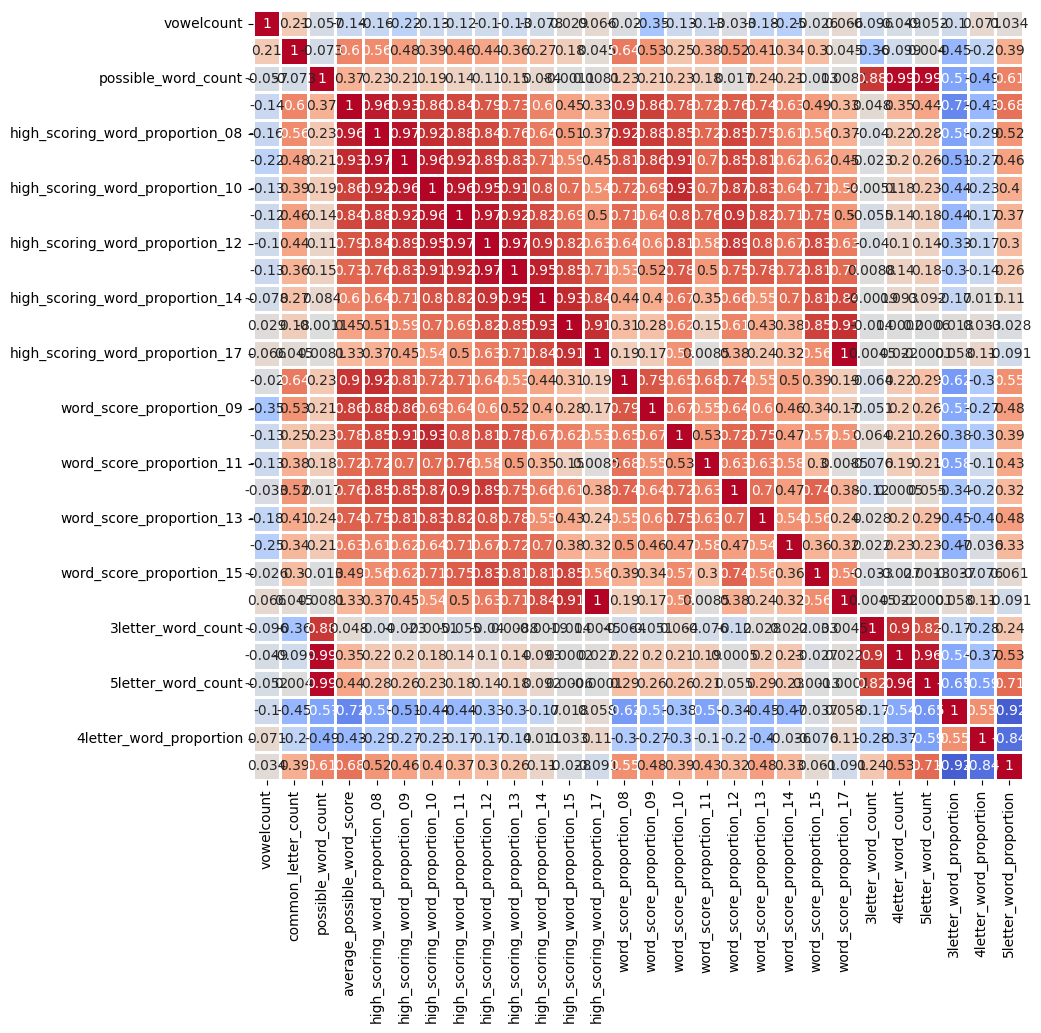

In [17]:
corr_matrix_all = df.corr(numeric_only=True)

# Round the correlation matrix to 2 decimal places
corr_matrix_rounded_all = corr_matrix_all.round(4)

sns.heatmap(corr_matrix_rounded_all, 
            annot=True,      # Display correlation values inside the heatmap cells.
            vmin=-1, vmax=1, # Define the limits of the color scale
            square=True,     # Make sure cells stay square
            #xticklabels=list(df.columns),
            cmap="coolwarm", # Set the color map
            linewidths=1,    # Lines between the cells
            cbar=False
            )
fig = plt.gcf()
fig.set_size_inches( 13, 10)
plt.show()


In [18]:
corr_matrix = df.corrwith(dayScores["scores"])

# Round the correlation matrix to 2 decimal places
corr_matrix_rounded = corr_matrix.round(2)


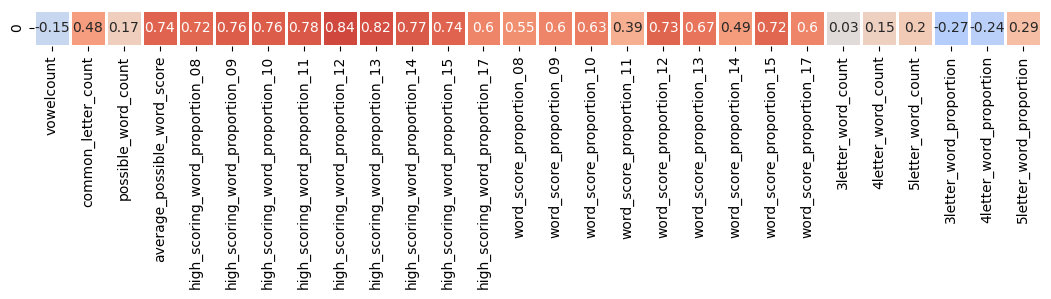

In [19]:
sns.heatmap([corr_matrix_rounded], 
            annot=True,      # Display correlation values inside the heatmap cells.
            vmin=-1, vmax=1, # Define the limits of the color scale
            square=True,     # Make sure cells stay square
            xticklabels=list(df.columns),
            cmap="coolwarm", # Set the color map
            linewidths=1,    # Lines between the cells
            cbar=False
            )
fig = plt.gcf()
fig.set_size_inches( 13, 10)
plt.show()


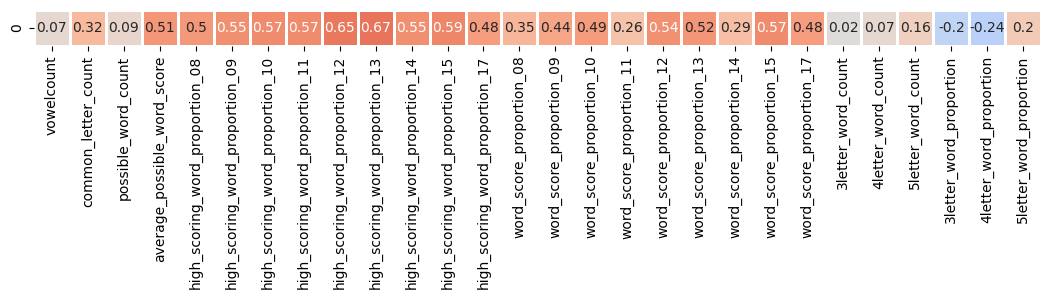

In [20]:
corr_matrix = df.corrwith(dayScores["scores"], method="kendall")
corr_matrix_rounded = corr_matrix.round(2)

sns.heatmap([corr_matrix_rounded], 
            annot=True,      # Display correlation values inside the heatmap cells.
            vmin=-1, vmax=1, # Define the limits of the color scale
            square=True,     # Make sure cells stay square
            xticklabels=list(df.columns),
            cmap="coolwarm", # Set the color map
            linewidths=1,    # Lines between the cells
            cbar=False
            )
fig = plt.gcf()
fig.set_size_inches( 13, 10)
plt.show()


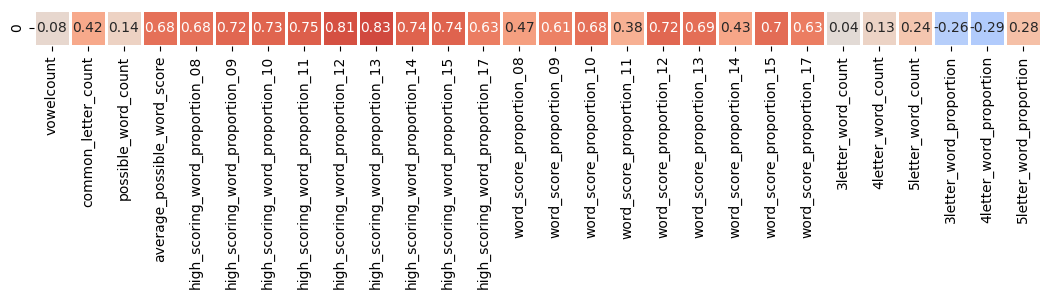

In [21]:
corr_matrix = df.corrwith(dayScores["scores"], method="spearman")
corr_matrix_rounded = corr_matrix.round(2)

sns.heatmap([corr_matrix_rounded], 
            annot=True,      # Display correlation values inside the heatmap cells.
            vmin=-1, vmax=1, # Define the limits of the color scale
            square=True,     # Make sure cells stay square
            xticklabels=list(df.columns),
            cmap="coolwarm", # Set the color map
            linewidths=1,    # Lines between the cells
            cbar=False
            )
fig = plt.gcf()
fig.set_size_inches( 13, 10)
plt.show()


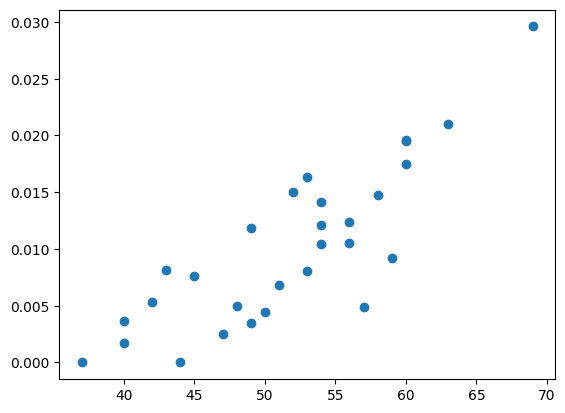

In [22]:
plt.scatter(dayScores["scores"], df['high_scoring_word_proportion_12'])
plt.show()


In [23]:
print(scipy.stats.spearmanr(dayScores["scores"], df['high_scoring_word_proportion_12']))

SignificanceResult(statistic=np.float64(0.809424699702185), pvalue=np.float64(1.0572612273702565e-07))


In [24]:
x = dayScores["scores"]
y = df['high_scoring_word_proportion_12'].values.reshape((-1, 1))

model1 = LinearRegression()
model1.fit(y, x)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[905.46]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,42.59
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[0.04]


In [35]:
new_data_stats = get_new_data_stats("ilbaufomedalimuoaynosihgl")

actual = 44

In [36]:
model1_selected_features = new_data_stats['high_scoring_word_proportion_12']

result1 = model1.predict(np.array(model1_selected_features).reshape(1, -1))
print(result1)

[43.22995716]


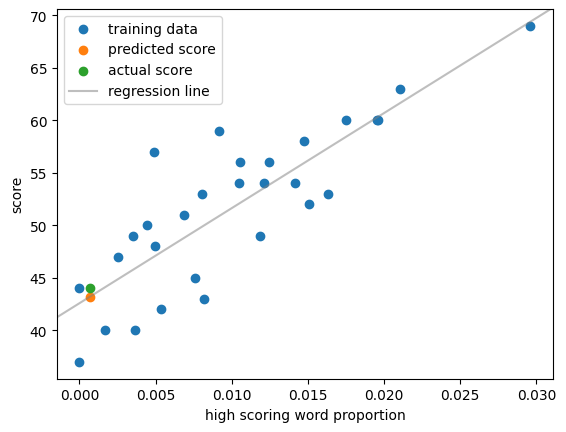

In [37]:
plt.scatter(df['high_scoring_word_proportion_12'], dayScores["scores"], label="training data",zorder=0)



plt.scatter(model1_selected_features, result1, label="predicted score", zorder=2)
plt.scatter(model1_selected_features, actual, label="actual score", zorder=2)

plt.plot([model1_selected_features, model1_selected_features], [result1[0],actual], ':r', zorder=1)

plt.axline((0, model1.intercept_), slope=model1.coef_[0], color='C7', alpha=0.5, label='regression line')

plt.legend()
plt.xlabel("high scoring word proportion")
plt.ylabel("score")
plt.show()


testing out polynomial regression instead of just linear:

In [38]:
y_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(y)

model2 = LinearRegression().fit(y_, x)

[42.73902671]


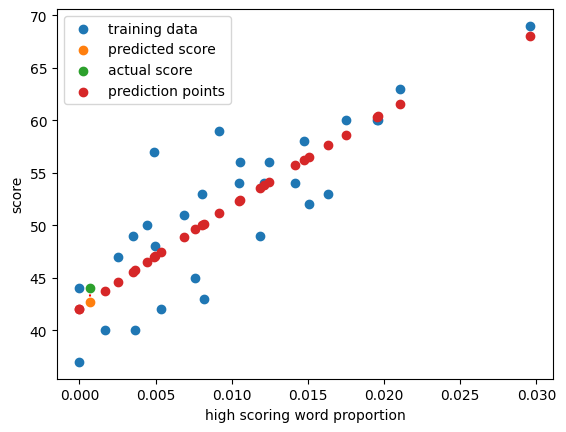

In [39]:
plt.scatter(df['high_scoring_word_proportion_12'], dayScores["scores"], label="training data",zorder=0)

model2_selected_features = new_data_stats['high_scoring_word_proportion_12']

new_data_stats_transformed = PolynomialFeatures(degree=2, include_bias=False).fit_transform(np.array(model2_selected_features).reshape(1, -1))
result2 = model2.predict(new_data_stats_transformed)
print(result2)

plt.scatter(model2_selected_features, result2, label="predicted score", zorder=2)
plt.scatter(model2_selected_features, actual, label="actual score", zorder=2)

plt.plot([model2_selected_features, model2_selected_features], [result2[0],actual], ':r', zorder=1)

plt.scatter(df['high_scoring_word_proportion_12'], model2.predict(y_), label="prediction points", zorder=1)

plt.legend()
plt.xlabel("high scoring word proportion")
plt.ylabel("score")
plt.show()

In [40]:
selected_features3 = ['high_scoring_word_proportion_12', 'common_letter_count', 'average_possible_word_score', "word_score_proportion_08","word_score_proportion_09","word_score_proportion_10","word_score_proportion_12","word_score_proportion_13","word_score_proportion_15","word_score_proportion_17"]
y3 = df[selected_features3]

y3_ = PolynomialFeatures( include_bias=False).fit_transform(y3)

model3 = LinearRegression()
model3.fit(y3_, x)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](65,)","[-1539.94, 24.13, 54.48,..., -5.46, 17.13, -23.1 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-209.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,65
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(23)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](29,)","[394.27, 22.91, 1.8 ,..., 0. , 0. , 0. ]"


[39.12503541]


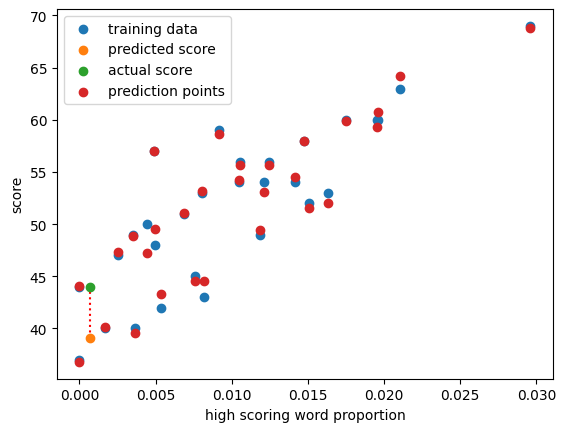

In [41]:
model3_selected_features = new_data_stats[selected_features3]

plt.scatter(df['high_scoring_word_proportion_12'], dayScores["scores"], label="training data",zorder=0)

predict_data_source3_ = PolynomialFeatures( include_bias=False).fit_transform(model3_selected_features)#.reshape(1, -1)
result3 = model3.predict(predict_data_source3_)
print(result3)

plt.scatter(model3_selected_features['high_scoring_word_proportion_12'], result3, label="predicted score", zorder=2)
plt.scatter(model3_selected_features['high_scoring_word_proportion_12'], actual, label="actual score", zorder=2)

plt.plot([model3_selected_features['high_scoring_word_proportion_12'], model3_selected_features['high_scoring_word_proportion_12']], [result3[0],actual], ':r', zorder=1)

plt.scatter(df['high_scoring_word_proportion_12'], model3.predict(y3_), label="prediction points", zorder=1)

plt.legend()
plt.xlabel("high scoring word proportion")
plt.ylabel("score")
plt.show()

[49.8118653]


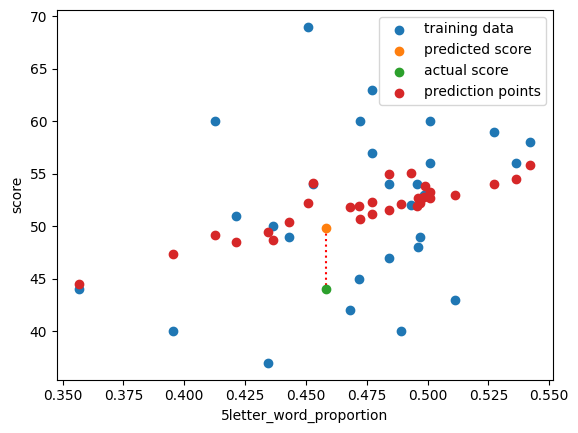

In [42]:
selected_features3 = ['3letter_word_proportion', '4letter_word_proportion', '5letter_word_proportion']
y3 = df[selected_features3]

y3_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(y3)

model3 = LinearRegression()
model3.fit(y3_, x)

model3_selected_features = new_data_stats[selected_features3]

plt.scatter(df['5letter_word_proportion'], dayScores["scores"], label="training data",zorder=0)

predict_data_source3_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(model3_selected_features)#.reshape(1, -1)
result3 = model3.predict(predict_data_source3_)
print(result3)

plt.scatter(model3_selected_features['5letter_word_proportion'], result3, label="predicted score", zorder=2)
plt.scatter(model3_selected_features['5letter_word_proportion'], actual, label="actual score", zorder=2)

plt.plot([model3_selected_features['5letter_word_proportion'], model3_selected_features['5letter_word_proportion']], [result3[0],actual], ':r', zorder=1)

plt.scatter(df['5letter_word_proportion'], model3.predict(y3_), label="prediction points", zorder=1)

plt.legend()
plt.xlabel("5letter_word_proportion")
plt.ylabel("score")
plt.show()

[39.67887288]


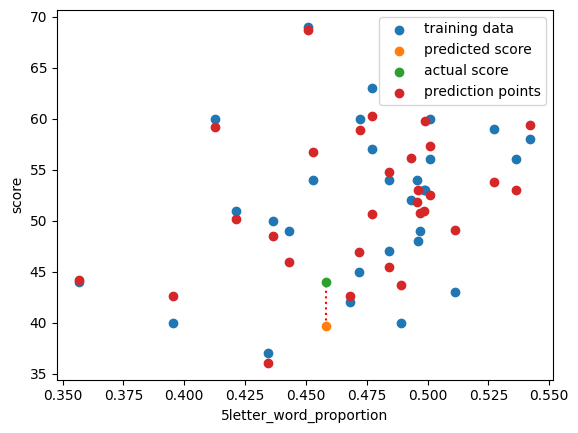

In [43]:
selected_features3 = ['high_scoring_word_proportion_12', 'average_possible_word_score', 'common_letter_count', '5letter_word_proportion']
y3 = df[selected_features3]

y3_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(y3)

model3 = LinearRegression()
model3.fit(y3_, x)

model3_selected_features = new_data_stats[selected_features3]

plt.scatter(df['5letter_word_proportion'], dayScores["scores"], label="training data",zorder=0)

predict_data_source3_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(model3_selected_features)#.reshape(1, -1)
result3 = model3.predict(predict_data_source3_)
print(result3)

plt.scatter(model3_selected_features['5letter_word_proportion'], result3, label="predicted score", zorder=2)
plt.scatter(model3_selected_features['5letter_word_proportion'], actual, label="actual score", zorder=2)

plt.plot([model3_selected_features['5letter_word_proportion'], model3_selected_features['5letter_word_proportion']], [result3[0],actual], ':r', zorder=1)

plt.scatter(df['5letter_word_proportion'], model3.predict(y3_), label="prediction points", zorder=1)

plt.legend()
plt.xlabel("5letter_word_proportion")
plt.ylabel("score")
plt.show()

[43.25071822]


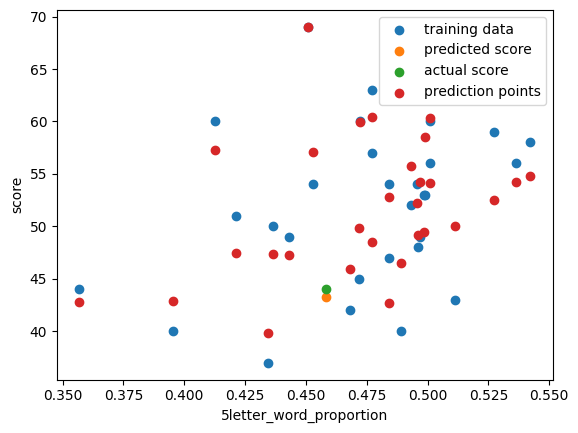

In [44]:
selected_features3 = ['high_scoring_word_proportion_12', 'average_possible_word_score', 'common_letter_count', '5letter_word_proportion']
y3 = df[selected_features3]

#y3_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(y3)

model3 = LinearRegression()
model3.fit(y3, x)

model3_selected_features = new_data_stats[selected_features3]

plt.scatter(df['5letter_word_proportion'], dayScores["scores"], label="training data",zorder=0)

#predict_data_source3_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(model3_selected_features)#.reshape(1, -1)
result3 = model3.predict(model3_selected_features)
print(result3)

plt.scatter(model3_selected_features['5letter_word_proportion'], result3, label="predicted score", zorder=2)
plt.scatter(model3_selected_features['5letter_word_proportion'], actual, label="actual score", zorder=2)

plt.plot([model3_selected_features['5letter_word_proportion'], model3_selected_features['5letter_word_proportion']], [result3[0],actual], ':r', zorder=1)

plt.scatter(df['5letter_word_proportion'], model3.predict(y3), label="prediction points", zorder=1)

plt.legend()
plt.xlabel("5letter_word_proportion")
plt.ylabel("score")
plt.show()